<a href="https://colab.research.google.com/github/VISHWAJA-028/CanteenHub/blob/main/160124737028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Statement: Analyze forest cover trends and distribution over Indian states**
#**Project ID:** CBIT/IT-1/EDAV/2025/CEP-26
#**Roll No:** 160124737028
#**Name**:Vishwaja Nakka
#**Dept of IT, Chaitanya Bharathi Institute of Technology, Hyderabad**
##**problem overview**
->India's forest cover plays a vital role in supporting biodiversity, regulating climate, and sustaining rural livelihoods. ->Analyzing forest cover trends and their distribution across various Indian states provides insights into regional ecological health, the effectiveness of conservation efforts, and patterns of deforestation or afforestation.
->This project explores the size, type, and changes in forest cover throughout India's states by using statistical and visualization techniques, enabling data-driven policy and environmental management decisions.
## Dataset Link:https://data.gov.in/resources/forest-cover-area-india
## Environment:
Python version (e.g., 3.8+)
Libraries: numpy, pandas, matplotlib, seaborn
##**Q1: Calculate mean forest cover area (Bloom’s Level: 3)**
->The mean, or average, is a measure of central tendency that sums all values in a dataset and divides by the number of items.
->Calculating the mean forest cover area gives insight into the typical size of forest cover across all Indian states.
##**Using the pandas library, the .mean() function computes this average efficiently.**
import pandas as pd
# Assume df is your DataFrame and 'Forest_Cover_Area' is the relevant column


In [2]:
import pandas as pd
import numpy as np
# Replace 'your_file_path.csv' with the actual path to your CSV file
df = pd.read_csv("/content/vishwaja.csv")

# Display column names to help identify the correct names
print("DataFrame columns:")
print(df.columns)

mean_forest_cover = df[['2009 Forest Cover', '2010 Forest Cover']].mean()
print("Q1: Mean Forest Cover Area (sq.km):")
print(mean_forest_cover)
print("\n")

DataFrame columns:
Index(['State', 'Year', 'Satellite and Sensor', 'Data Period',
       '2009 Forest Cover', '2010 Forest Cover'],
      dtype='object')
Q1: Mean Forest Cover Area (sq.km):
2009 Forest Cover    42750.666667
2010 Forest Cover    38445.944444
dtype: float64




#**Filter states by forest cover type**

In [ ]:
def forest_cover_type(area):
    if area > 50000:
        return "High"
    elif area >= 20000:
        return "Medium"
    else:
        return "Low"

df['Cover_Type'] = df['2010 Forest Cover'].apply(forest_cover_type)

# Example: Filter only 'High' forest cover states
high_cover_states = df[df['Cover_Type'] == 'High']
print("Q2: States with High Forest Cover in 2010:")
print(high_cover_states[['State', '2010 Forest Cover', 'Cover_Type']])
print("\n")

Q2: States with High Forest Cover in 2010:
                State  2010 Forest Cover Cover_Type
1   Arunachal Pradesh              67410       High
4         Chhatisgarh              55674       High
14     Madhya Pradesh              77700       High
15        Maharashtra              50646       High
35              Total             692027       High




#**Fill missing forest cover data (BL-4)**

In [ ]:
df_filled = df.fillna(df.mean(numeric_only=True))
print("Q3: Missing forest cover data filled using column means.")
print(df_filled.head())
print("\n")

Q3: Missing forest cover data filled using column means.
               State  Year  Satellite and Sensor  Data Period  \
0     Andhra Pradesh   NaN                   NaN          NaN   
1  Arunachal Pradesh   NaN                   NaN          NaN   
2              Assam   NaN                   NaN          NaN   
3              Bihar   NaN                   NaN          NaN   
4        Chhatisgarh   NaN                   NaN          NaN   

   2009 Forest Cover  2010 Forest Cover Cover_Type  
0              63814              46389     Medium  
1              51540              67410       High  
2              26832              27673     Medium  
3               6473               6845        Low  
4              59772              55674       High  




#**Group data by cover type and calculate average (BL-4)**

In [ ]:
grouped_data = df_filled.groupby('Cover_Type')[['2009 Forest Cover', '2010 Forest Cover']].mean()
print("Q4: Average forest cover by Cover Type:")
print(grouped_data)
print("\n")

Q4: Average forest cover by Cover Type:
            2009 Forest Cover  2010 Forest Cover
Cover_Type                                      
High            207490.400000       188691.40000
Low               9267.086957         8165.26087
Medium           36053.625000        31599.50000




#**Visualize forest cover change using plots (BL-5)**

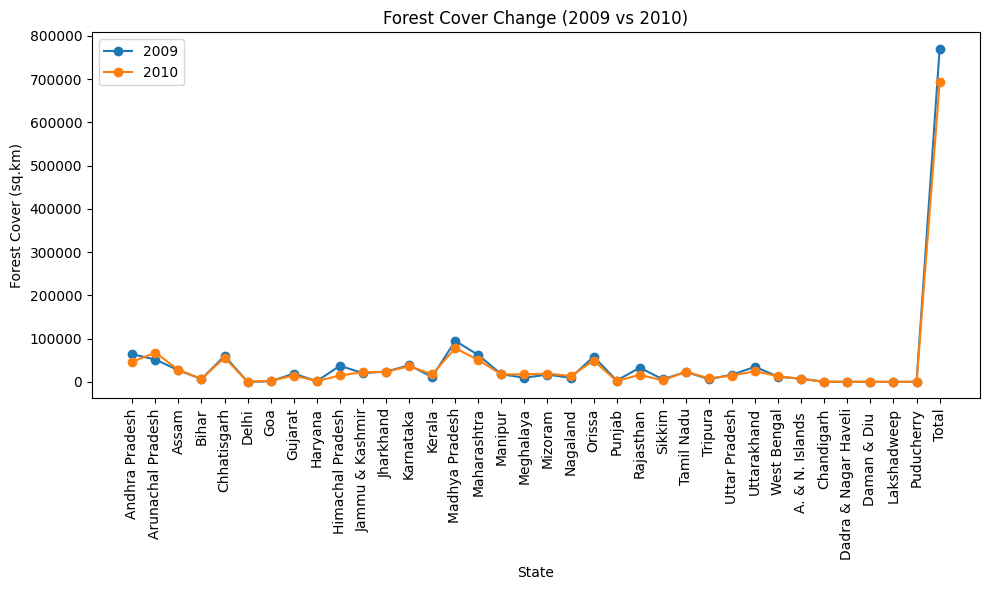

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(df['State'], df['2009 Forest Cover'], marker='o', label='2009')
plt.plot(df['State'], df['2010 Forest Cover'], marker='o', label='2010')
plt.xticks(rotation=90)
plt.title('Forest Cover Change (2009 vs 2010)')
plt.xlabel('State')
plt.ylabel('Forest Cover (sq.km)')
plt.legend()
plt.tight_layout()
plt.show()